## 1. Setup

In [1]:
!pip install -q wfdb PyWavelets

import os, glob, time
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import butter, filtfilt, iirnotch, kaiserord, firwin
import pywt
import wfdb
from wfdb import processing

plt.rcParams['figure.dpi'] = 110


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 8.8 MB/s eta 0:00:00


## 2. Data Loading

In [2]:
# Search recursively from the dataset root for .dat files
candidates = glob.glob('/kaggle/input/datasets/retalashrafali/mit-bih-arrhythmia-nu/**/*.dat', recursive=True)
print(f"Found {len(candidates)} .dat files")
print(candidates[:5])

DATA_DIR = os.path.dirname(candidates[0])
print("\nUsing DATA_DIR =", DATA_DIR)
print(sorted(os.listdir(DATA_DIR))[:15])


Found 71 .dat files
['/kaggle/input/datasets/retalashrafali/mit-bih-arrhythmia-nu/mit-bih-arrhythmia-database-1.0.0/103.dat', '/kaggle/input/datasets/retalashrafali/mit-bih-arrhythmia-nu/mit-bih-arrhythmia-database-1.0.0/113.dat', '/kaggle/input/datasets/retalashrafali/mit-bih-arrhythmia-nu/mit-bih-arrhythmia-database-1.0.0/202.dat', '/kaggle/input/datasets/retalashrafali/mit-bih-arrhythmia-nu/mit-bih-arrhythmia-database-1.0.0/217.dat', '/kaggle/input/datasets/retalashrafali/mit-bih-arrhythmia-nu/mit-bih-arrhythmia-database-1.0.0/219.dat']

Using DATA_DIR = /kaggle/input/datasets/retalashrafali/mit-bih-arrhythmia-nu/mit-bih-arrhythmia-database-1.0.0
['100.atr', '100.dat', '100.hea', '100.xws', '101.atr', '101.dat', '101.hea', '101.xws', '102-0.atr', '102.atr', '102.dat', '102.hea', '102.xws', '103.atr', '103.dat']


In [3]:
records = sorted(set(os.path.basename(f).replace('.dat', '') for f in glob.glob(f'{DATA_DIR}/*.dat')))
print(f"Total records: {len(records)}")
print(records)


Total records: 48
['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']


In [4]:
sample_rec = wfdb.rdrecord(os.path.join(DATA_DIR, records[0]))

print("Record name        :", sample_rec.record_name)
print("Sampling frequency  :", sample_rec.fs, "Hz")
print("Signal length       :", sample_rec.sig_len, "samples =", sample_rec.sig_len / sample_rec.fs, "s")
print("Number of leads     :", sample_rec.n_sig)
print("Lead names          :", sample_rec.sig_name)
print("Units               :", sample_rec.units)
print("ADC gain            :", sample_rec.adc_gain)
print("Comments            :", sample_rec.comments)


Record name        : 100
Sampling frequency  : 360 Hz
Signal length       : 650000 samples = 1805.5555555555557 s
Number of leads     : 2
Lead names          : ['MLII', 'V5']
Units               : ['mV', 'mV']
ADC gain            : [200.0, 200.0]
Comments            : ['69 M 1085 1629 x1', 'Aldomet, Inderal']


In [5]:
all_symbols = Counter()
for rec_name in records:
    try:
        ann = wfdb.rdann(os.path.join(DATA_DIR, rec_name), 'atr')
        all_symbols.update(ann.symbol)
    except Exception as e:
        print(f"Skipped {rec_name}: {e}")

print("Beat symbol counts across all 48 records:")
for sym, count in all_symbols.most_common(15):
    print(f"  {sym!r:>4}: {count}")


Beat symbol counts across all 48 records:
   'N': 75052
   'L': 8075
   'R': 7259
   'V': 7130
   '/': 7028
   'A': 2546
   '+': 1291
   'f': 982
   'F': 803
   '~': 616
   '!': 472
   '"': 437
   'j': 229
   'x': 193
   'a': 150


## 3. Noise Profiling

Identify which record is dominated by baseline wander (worst case for
denoising) and which is cleanest, so all filter comparisons below are done
on a representative "hard" case.

In [6]:
def band_power_fraction(x, lo, hi, fs):
    f, p = signal.welch(x, fs=fs, nperseg=2048)
    total = np.trapezoid(p, f)
    m = (f >= lo) & (f <= hi)
    return 100 * np.trapezoid(p[m], f[m]) / total if total > 0 else 0

noise_profile = []
for rec_name in records:
    rec = wfdb.rdrecord(os.path.join(DATA_DIR, rec_name))
    x = rec.p_signal[:, 0]   # MLII lead
    fs = rec.fs
    bw = band_power_fraction(x, 0, 0.5, fs)
    pl = band_power_fraction(x, 59, 61, fs)
    hf = band_power_fraction(x, 100, fs / 2, fs)
    noise_profile.append((rec_name, bw, pl, hf))

noise_profile.sort(key=lambda r: -r[1])
print(f"{'Record':<8}{'BaselineWander%':>16}{'Powerline%':>12}{'HighFreq%':>12}")
for r in noise_profile:
    print(f"{r[0]:<8}{r[1]:>16.2f}{r[2]:>12.3f}{r[3]:>12.4f}")


Record   BaselineWander%  Powerline%   HighFreq%
108                39.78       0.088      0.0235
121                28.05       0.002      0.0257
111                22.48       0.180      0.0297
222                21.15       0.288      0.0547
219                18.35       0.002      0.0051
114                17.37       0.459      0.0774
203                14.38       0.057      0.0095
228                14.26       0.056      0.0165
207                13.69       0.058      0.0130
116                13.69       0.004      0.0110
112                12.22       0.007      0.0304
124                12.09       0.001      0.0071
101                10.99       0.081      0.0208
234                10.23       0.003      0.0127
115                 9.64       0.002      0.0182
209                 9.49       0.104      0.0250
105                 8.46       0.033      0.0086
208                 7.56       0.054      0.0076
212                 7.50       0.114      0.0171
210                 

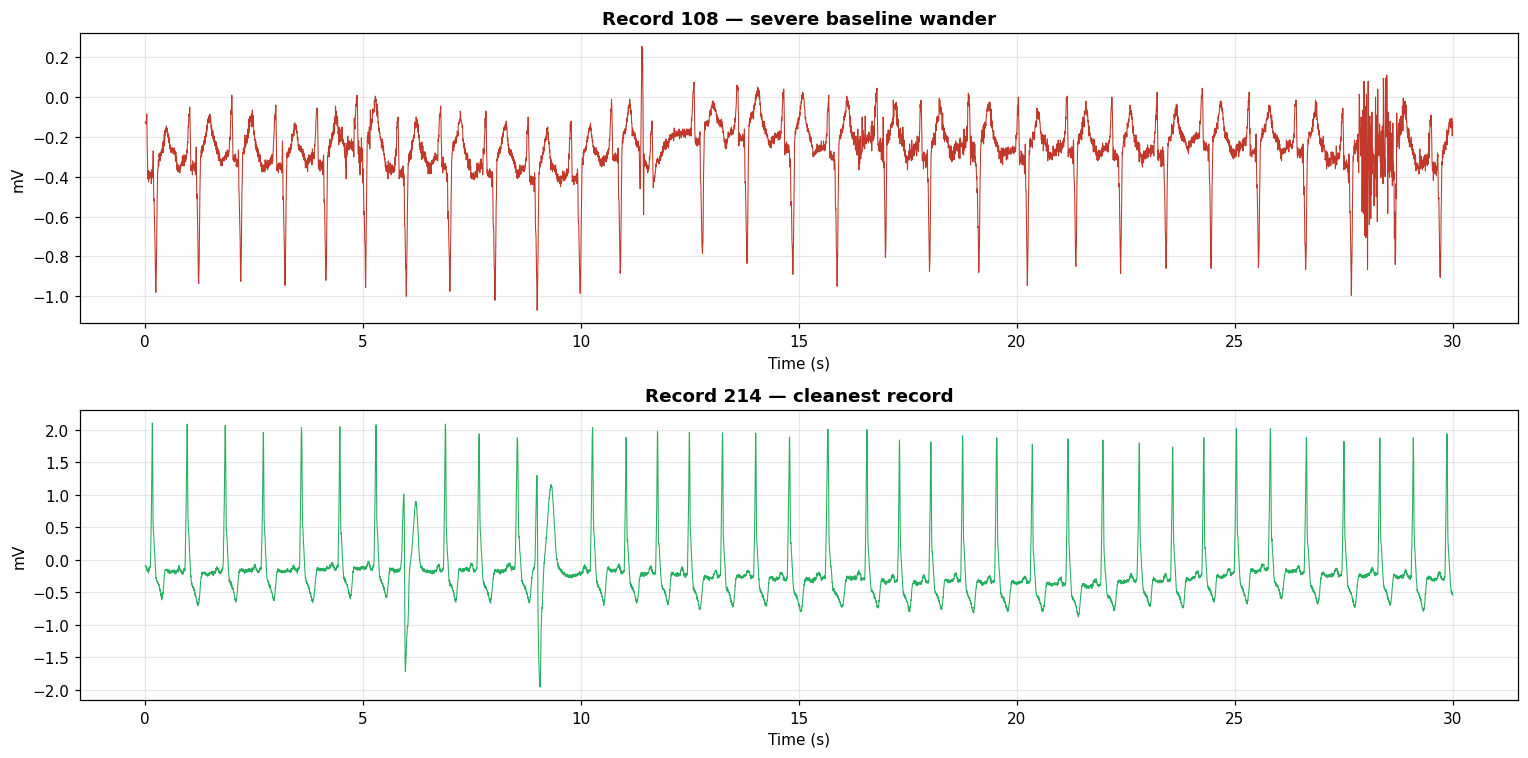

In [7]:
# Record 108 = worst baseline wander -> good demo/stress-test case
# Record 214 = cleanest -> contrast case
WORST_BW = '108'
CLEANEST = '214'

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
for ax, rec_name, title in [(axes[0], WORST_BW, f'Record {WORST_BW} — severe baseline wander'),
                             (axes[1], CLEANEST, f'Record {CLEANEST} — cleanest record')]:
    rec = wfdb.rdrecord(os.path.join(DATA_DIR, rec_name))
    x = rec.p_signal[:int(rec.fs * 30), 0]
    t = np.arange(len(x)) / rec.fs
    ax.plot(t, x, linewidth=0.7, color='#c0392b' if rec_name == WORST_BW else '#27ae60')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('mV'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


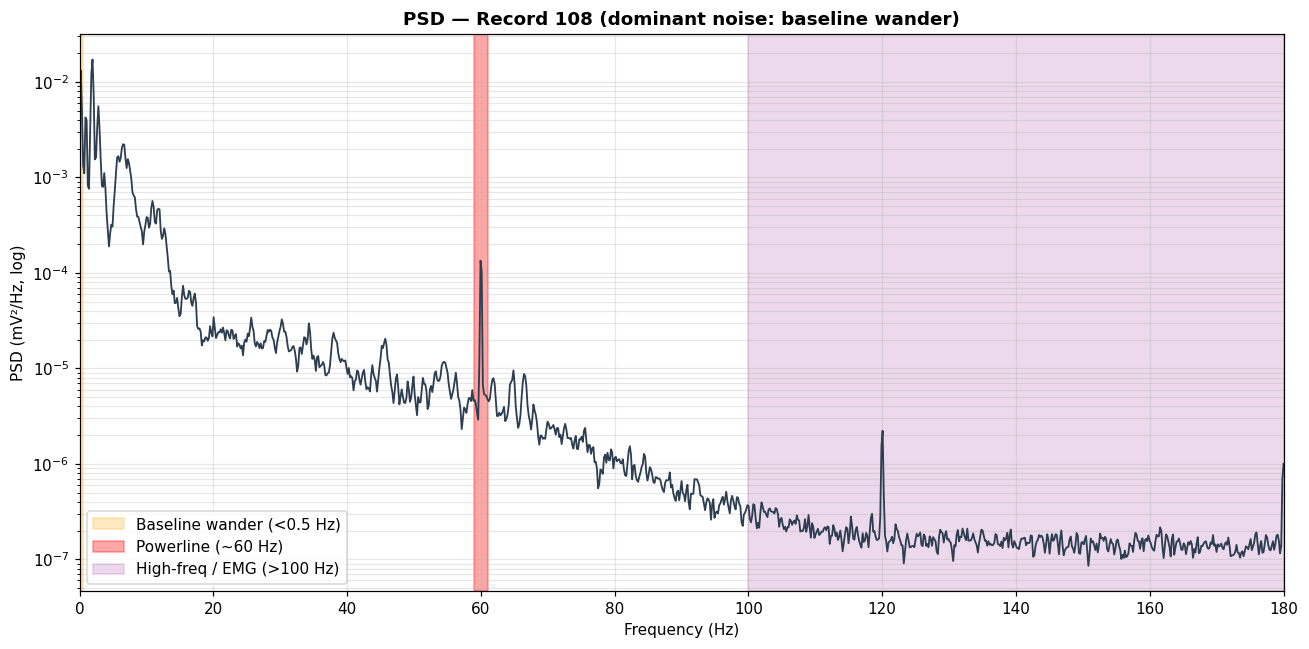

In [8]:
RECORD = WORST_BW
rec = wfdb.rdrecord(os.path.join(DATA_DIR, RECORD))
FS = rec.fs
x = rec.p_signal[:FS * 120, 0]
fs = FS
t = np.arange(len(x)) / fs

freqs, psd = signal.welch(x, fs=fs, nperseg=2048)
fig, ax = plt.subplots(figsize=(12, 6))
ax.semilogy(freqs, psd, color='#2c3e50', linewidth=1.2)
ax.axvspan(0, 0.5, color='orange', alpha=0.25, label='Baseline wander (<0.5 Hz)')
ax.axvspan(59, 61, color='red', alpha=0.35, label='Powerline (~60 Hz)')
ax.axvspan(100, fs / 2, color='purple', alpha=0.15, label='High-freq / EMG (>100 Hz)')
ax.set_xlim(0, 180)
ax.set_title(f'PSD — Record {RECORD} (dominant noise: baseline wander)', fontweight='bold')
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('PSD (mV²/Hz, log)')
ax.legend(); ax.grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()


## 4. Classical Filtering (Butterworth / Notch / FIR-Kaiser)

In [9]:
def highpass(x, cutoff=0.5, fs=FS, order=4):
    b, a = butter(order, cutoff / (fs / 2), btype='high')
    return filtfilt(b, a, x)

def lowpass(x, cutoff=35, fs=FS, order=4):
    b, a = butter(order, cutoff / (fs / 2), btype='low')
    return filtfilt(b, a, x)

def bandpass(x, low=0.5, high=35, fs=FS, order=4):
    b, a = butter(order, [low / (fs / 2), high / (fs / 2)], btype='band')
    return filtfilt(b, a, x)

def notch60(x, f0=60, Q=30, fs=FS):
    b, a = iirnotch(f0 / (fs / 2), Q)
    return filtfilt(b, a, x)

def fir_bandstop_kaiser(x, f0=60, notch_width=4, ripple_db=60, trans_width=2, fs=FS):
    nyq = fs / 2
    N, beta = kaiserord(ripple_db, trans_width / nyq)
    if N % 2 == 0:
        N += 1
    taps = firwin(N, [(f0 - notch_width / 2) / nyq, (f0 + notch_width / 2) / nyq],
                   window=('kaiser', beta), pass_zero='bandstop')
    return filtfilt(taps, [1.0], x)

def plot_fft(x, fs, title, ax):
    n = len(x)
    freqs = np.fft.rfftfreq(n, 1 / fs)
    mag = np.abs(np.fft.rfft(x)) / n
    ax.plot(freqs, mag, linewidth=0.8)
    ax.set_xlim(0, 100)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Hz'); ax.set_ylabel('|X(f)|')
    ax.axvline(60, color='r', linestyle='--', alpha=0.5, label='60Hz')
    ax.legend()


In [10]:

variants = {
    'raw':                 x,
    'highpass_only':       highpass(x),
    'bandpass_only':       bandpass(x),
    'bandpass+notch':      notch60(bandpass(x)),
    'bandpass+fir_kaiser': fir_bandstop_kaiser(bandpass(x)),
}

print(f"{'Variant':<20}{'BaselineWander%':>16}{'Powerline%':>12}{'HighFreq%':>12}")
for name, sig in variants.items():
    bw = band_power_fraction(sig, 0, 0.5, fs)
    pl = band_power_fraction(sig, 59, 61, fs)
    hf = band_power_fraction(sig, 100, fs / 2, fs)
    print(f"{name:<20}{bw:>16.3f}{pl:>12.4f}{hf:>12.4f}")


Variant              BaselineWander%  Powerline%   HighFreq%
raw                           12.450      0.2148      0.0610
highpass_only                  0.048      0.2534      0.0720
bandpass_only                  0.051      0.0000      0.0000
bandpass+notch                 0.051      0.0000      0.0000
bandpass+fir_kaiser            0.051      0.0000      0.0000


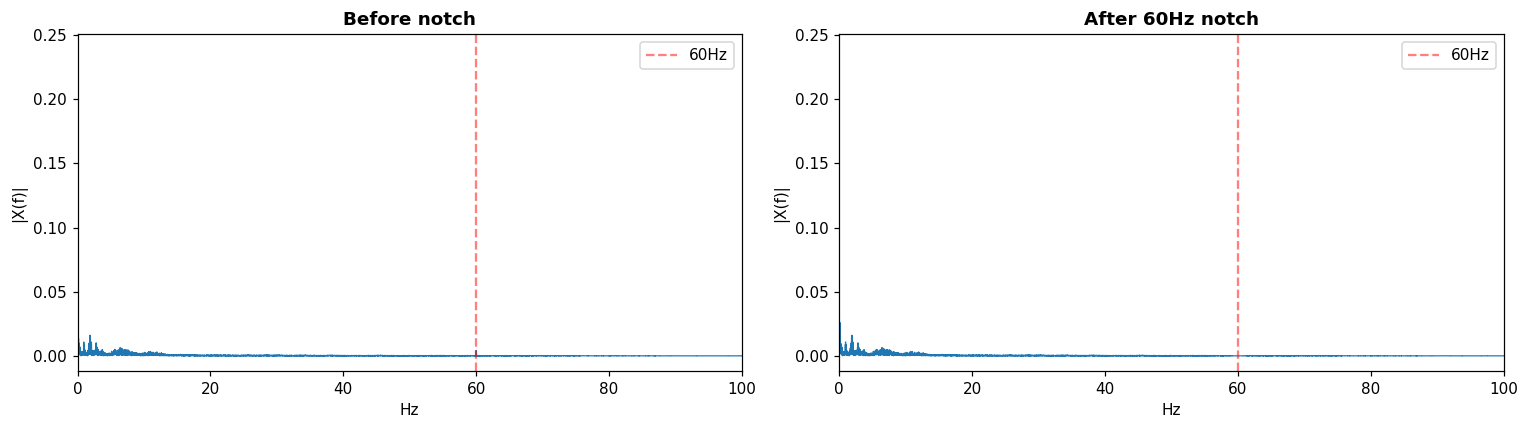

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_fft(x, fs, 'Before notch', axes[0])
plot_fft(notch60(x), fs, 'After 60Hz notch', axes[1])
plt.tight_layout(); plt.show()


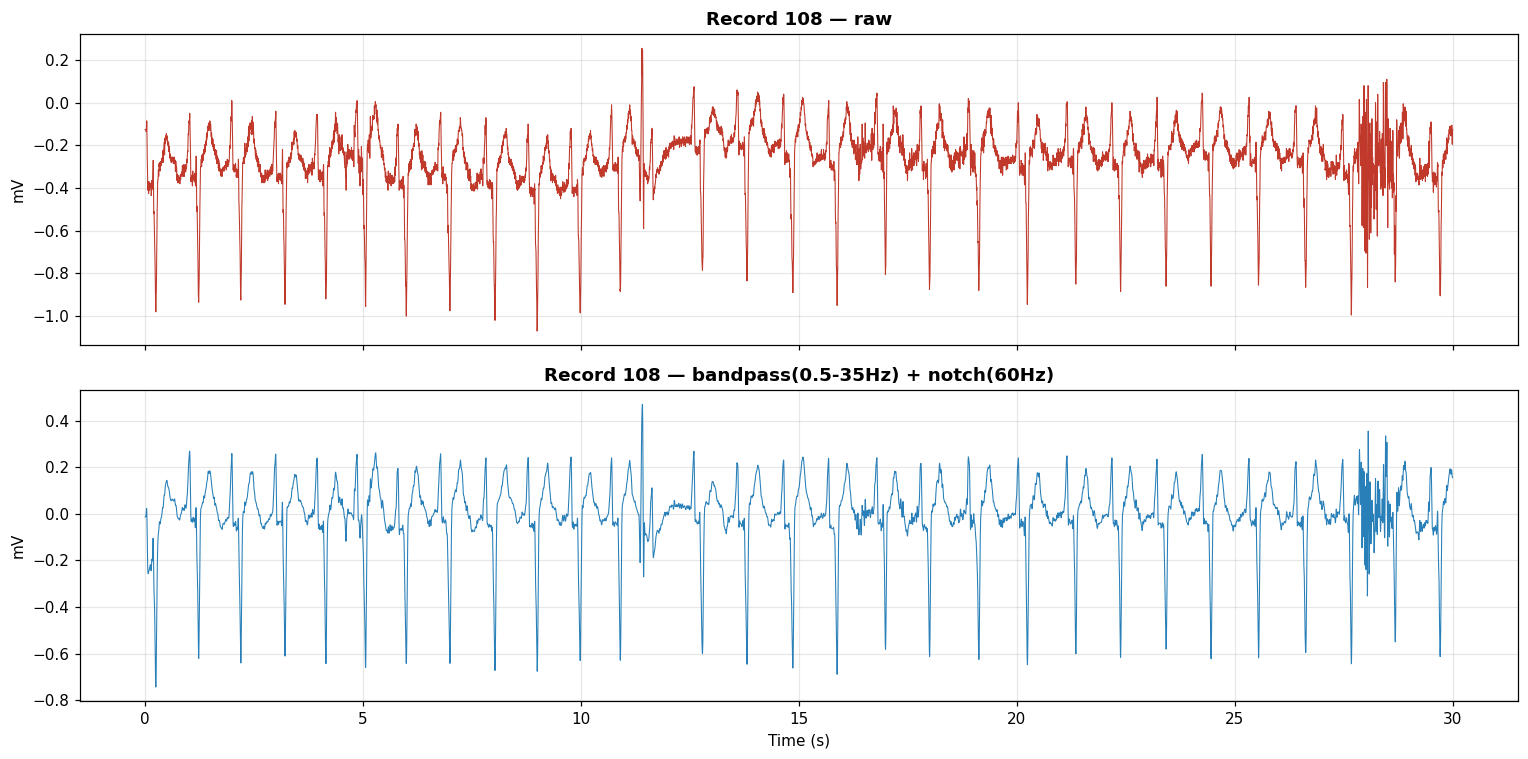

In [12]:
best_classical = variants['bandpass+notch']
t30 = np.arange(int(fs * 30)) / fs

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(t30, x[:int(fs * 30)], linewidth=0.7, color='#c0392b')
axes[0].set_title(f'Record {WORST_BW} — raw', fontweight='bold')
axes[1].plot(t30, best_classical[:int(fs * 30)], linewidth=0.7, color='#2980b9')
axes[1].set_title(f'Record {WORST_BW} — bandpass(0.5-35Hz) + notch(60Hz)', fontweight='bold')
for ax in axes:
    ax.set_ylabel('mV'); ax.grid(alpha=0.3)
axes[1].set_xlabel('Time (s)')
plt.tight_layout(); plt.show()


## 5. Wavelet Denoising (SWT & DWT)

In [13]:
def swt_denoise(x, wavelet='rbio3.9', level=5, threshold_scale=0.5):
    n = len(x)
    pad = (2 ** level - n % 2 ** level) % 2 ** level
    x_pad = np.pad(x, (0, pad), mode='reflect')
    coeffs = pywt.swt(x_pad, wavelet, level=level)
    denoised_coeffs = []
    for i, (cA, cD) in enumerate(coeffs):
        sigma = np.median(np.abs(cD)) / 0.6745
        thresh = threshold_scale * sigma * np.sqrt(2 * np.log(len(cD)))
        cD_thresh = pywt.threshold(cD, thresh, mode='soft')
        if i == len(coeffs) - 1:          # last level = baseline component
            cA = cA - np.median(cA)
        denoised_coeffs.append((cA, cD_thresh))
    rec = pywt.iswt(denoised_coeffs, wavelet)
    return rec[:n]

def dwt_denoise(x, wavelet='rbio3.9', level=5, threshold_scale=0.5):
    coeffs = pywt.wavedec(x, wavelet, level=level)
    cA = coeffs[0] - np.median(coeffs[0])
    denoised = [cA]
    for cD in coeffs[1:]:
        sigma = np.median(np.abs(cD)) / 0.6745
        thresh = threshold_scale * sigma * np.sqrt(2 * np.log(len(cD)))
        denoised.append(pywt.threshold(cD, thresh, mode='soft'))
    rec = pywt.waverec(denoised, wavelet)
    return rec[:len(x)]

swt_sig = swt_denoise(x)
dwt_sig = dwt_denoise(x)
variants['swt_rbio3.9'] = swt_sig
variants['dwt_rbio3.9'] = dwt_sig

print(f"{'Variant':<20}{'BaselineWander%':>16}{'Powerline%':>12}{'HighFreq%':>12}")
for name, sig in variants.items():
    bw = band_power_fraction(sig, 0, 0.5, fs)
    pl = band_power_fraction(sig, 59, 61, fs)
    hf = band_power_fraction(sig, 100, fs / 2, fs)
    print(f"{name:<20}{bw:>16.3f}{pl:>12.4f}{hf:>12.4f}")


Variant              BaselineWander%  Powerline%   HighFreq%
raw                           12.450      0.2148      0.0610
highpass_only                  0.048      0.2534      0.0720
bandpass_only                  0.051      0.0000      0.0000
bandpass+notch                 0.051      0.0000      0.0000
bandpass+fir_kaiser            0.051      0.0000      0.0000
swt_rbio3.9                   15.446      0.0111      0.0034
dwt_rbio3.9                   14.645      0.0162      0.0091


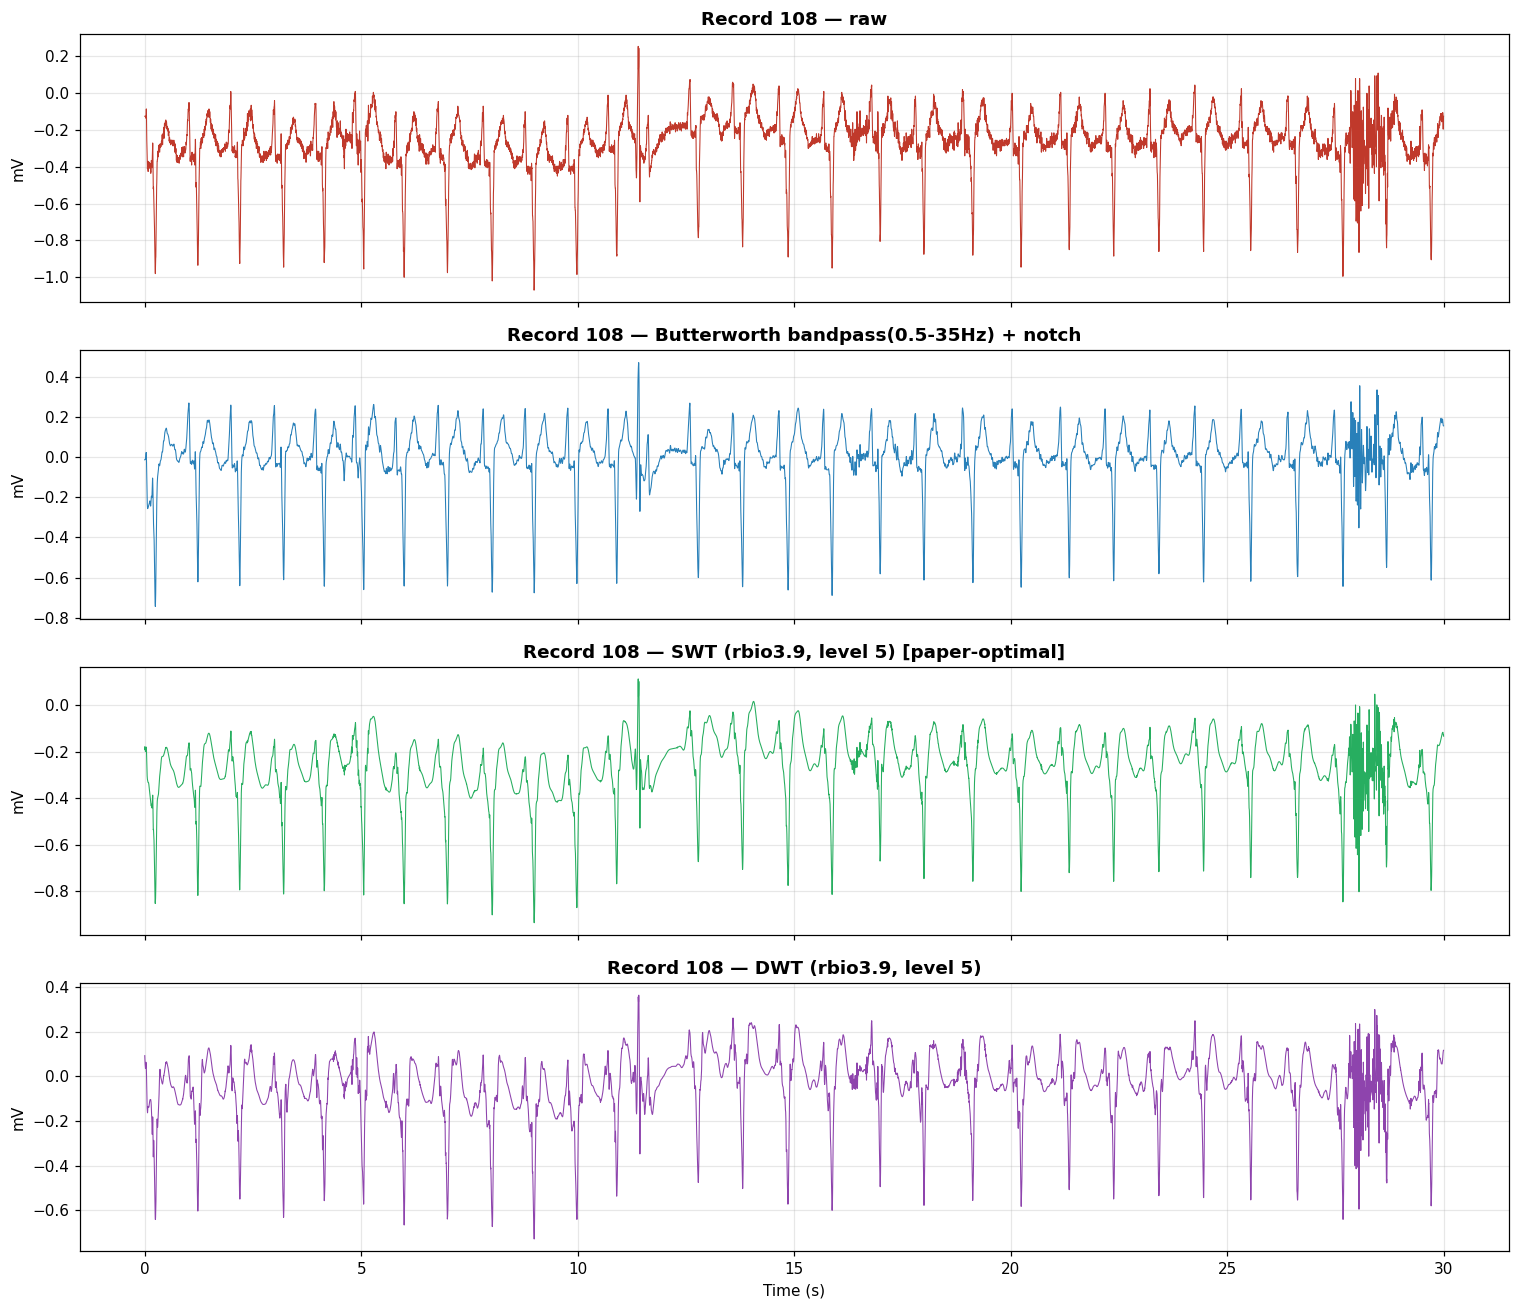

In [37]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(t30, x[:int(fs * 30)], linewidth=0.7, color='#c0392b')
axes[0].set_title(f'Record {WORST_BW} — raw', fontweight='bold')

axes[1].plot(t30, variants['bandpass+notch'][:int(fs * 30)], linewidth=0.7, color='#2980b9')
axes[1].set_title(f'Record {WORST_BW} — Butterworth bandpass(0.5-35Hz) + notch', fontweight='bold')

axes[2].plot(t30, swt_sig[:int(fs * 30)], linewidth=0.7, color='#27ae60')
axes[2].set_title(f'Record {WORST_BW} — SWT (rbio3.9, level 5) [paper-optimal]', fontweight='bold')

axes[3].plot(t30, dwt_sig[:int(fs * 30)], linewidth=0.7, color='#8e44ad')
axes[3].set_title(f'Record {WORST_BW} — DWT (rbio3.9, level 5)', fontweight='bold')

for ax in axes:
    ax.set_ylabel('mV'); ax.grid(alpha=0.3)
axes[3].set_xlabel('Time (s)')
plt.tight_layout(); plt.show()


## 6. Quantitative Comparison  SNR & Correlation

In [14]:
def snr_improvement(raw, filtered):
    noise = raw - filtered
    signal_power = np.sum(filtered ** 2)
    noise_power = np.sum(noise ** 2)
    return 10 * np.log10(signal_power / noise_power) if noise_power > 0 else np.inf

print(f"{'Variant':<20}{'SNR (dB)':>10}{'Corr-with-raw':>16}")
for name in ['bandpass+notch', 'swt_rbio3.9', 'dwt_rbio3.9']:
    snr = snr_improvement(x, variants[name])
    corr = np.corrcoef(x, variants[name])[0, 1]
    print(f"{name:<20}{snr:>10.2f}{corr:>16.4f}")


Variant               SNR (dB)   Corr-with-raw
bandpass+notch           -5.20          0.8397
swt_rbio3.9              16.64          0.9699
dwt_rbio3.9              -3.50          0.9646


In [15]:
# Robustness check: does SWT stay the best choice across other records too,
# not just the worst-case one (108)?
print(f"{'Record':<8}{'Technique':<20}{'SNR(dB)':>10}{'Corr':>8}")
for rec_name in ['108', '121', '111', '222']:
    rec_r = wfdb.rdrecord(os.path.join(DATA_DIR, rec_name))
    xr = rec_r.p_signal[:, 0]
    v = {
        'bandpass+notch': notch60(bandpass(xr)),
        'swt_rbio3.9':    swt_denoise(xr),
        'dwt_rbio3.9':    dwt_denoise(xr),
    }
    for name, sig in v.items():
        snr = snr_improvement(xr, sig)
        corr = np.corrcoef(xr, sig)[0, 1]
        print(f"{rec_name:<8}{name:<20}{snr:>10.2f}{corr:>8.4f}")


Record  Technique              SNR(dB)    Corr
108     bandpass+notch           -5.68  0.5927
108     swt_rbio3.9              18.55  0.9900
108     dwt_rbio3.9               1.93  0.9856
121     bandpass+notch          -13.63  0.5926
121     swt_rbio3.9              28.79  0.9948
121     dwt_rbio3.9              -8.88  0.9914
111     bandpass+notch           -1.94  0.7479
111     swt_rbio3.9              13.49  0.9728
111     dwt_rbio3.9               2.25  0.9580
222     bandpass+notch           -3.87  0.7510
222     swt_rbio3.9              14.58  0.9739
222     dwt_rbio3.9               0.83  0.9642


## 7. Batch Preprocessing the Chosen Method (SWT) to All Records


In [16]:
def preprocess_record(rec_name, data_dir=DATA_DIR):
    rec = wfdb.rdrecord(os.path.join(data_dir, rec_name))
    x_r = rec.p_signal[:, 0]
    return swt_denoise(x_r), rec.fs

cleaned = {}
fs_by_record = {}
t0 = time.time()
for rec_name in records:
    sig, fs_r = preprocess_record(rec_name)
    cleaned[rec_name] = sig
    fs_by_record[rec_name] = fs_r
print(f"Preprocessed {len(cleaned)} records in {time.time() - t0:.1f}s")


Preprocessed 48 records in 15.3s


## 8. R-Peak Detection

In [17]:
def detect_rpeaks(sig, fs):
    xqrs = processing.XQRS(sig=sig, fs=fs)
    xqrs.detect(verbose=False)
    return xqrs.qrs_inds

fs_108 = fs_by_record['108']
r_peaks = detect_rpeaks(cleaned['108'], fs_108)
print(f"Detected {len(r_peaks)} R-peaks in record 108")


Detected 1767 R-peaks in record 108


In [18]:
def evaluate_detection(rec_name, cleaned_sig, fs, tol_ms=100):
    ann = wfdb.rdann(os.path.join(DATA_DIR, rec_name), 'atr')
    true_peaks = ann.sample[np.isin(ann.symbol, list('NLRBAaJSVrFejnE/fQ?'))]  # beat annotations only
    detected = detect_rpeaks(cleaned_sig, fs)

    tol = int(tol_ms / 1000 * fs)
    matched = 0
    used = np.zeros(len(detected), dtype=bool)
    for tp in true_peaks:
        diffs = np.abs(detected - tp)
        idx = np.argmin(diffs)
        if diffs[idx] <= tol and not used[idx]:
            matched += 1
            used[idx] = True

    sensitivity = matched / len(true_peaks) if len(true_peaks) else 0
    precision = matched / len(detected) if len(detected) else 0
    return len(true_peaks), len(detected), matched, sensitivity, precision

print(f"{'Record':<8}{'True':>6}{'Detected':>10}{'Matched':>9}{'Sens':>8}{'Prec':>8}")
for rec_name in ['108', '121', '111', '222', '100']:
    n_true, n_det, n_match, sens, prec = evaluate_detection(rec_name, cleaned[rec_name], fs_by_record[rec_name])
    print(f"{rec_name:<8}{n_true:>6}{n_det:>10}{n_match:>9}{sens:>8.3f}{prec:>8.3f}")


Record    True  Detected  Matched    Sens    Prec
108       1763      1767     1733   0.983   0.981
121       1863      1862     1861   0.999   0.999
111       2124      2122     2122   0.999   1.000
222       2483      2470     2469   0.994   1.000
100       2273      2273     2273   1.000   1.000


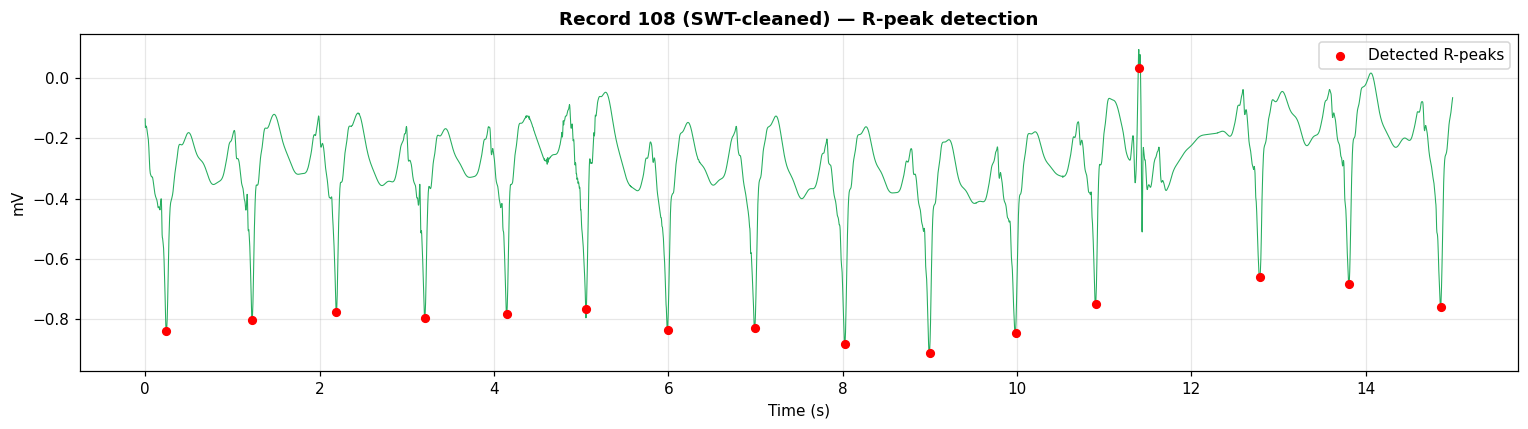

In [19]:
fig, ax = plt.subplots(figsize=(14, 4))
window = int(fs_108 * 15)
ax.plot(np.arange(window) / fs_108, cleaned['108'][:window], linewidth=0.7, color='#27ae60')
peaks_in_window = r_peaks[r_peaks < window]
ax.scatter(peaks_in_window / fs_108, cleaned['108'][peaks_in_window], color='red', s=25, zorder=5, label='Detected R-peaks')
ax.set_title('Record 108 (SWT-cleaned) — R-peak detection', fontweight='bold')
ax.set_xlabel('Time (s)'); ax.set_ylabel('mV'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 9. Beat Morphology Analysis


In [21]:
def extract_morphology(sig, r_peaks_in, fs):
    windows = {
        'P_wave':     (-0.20, -0.10),
        'QRS':        (-0.05,  0.05),
        'ST_segment': ( 0.06,  0.12),
        'T_wave':     ( 0.15,  0.35),
    }
    results = {k: [] for k in windows}
    r_amp = []

    for r in r_peaks_in:
        if r - int(0.3 * fs) < 0 or r + int(0.4 * fs) >= len(sig):
            continue
        local = sig[r - int(0.05 * fs): r + int(0.05 * fs)]
        r_amp.append(np.max(local) - np.min(local))

        for name, (start, end) in windows.items():
            i0 = r + int(start * fs)
            i1 = r + int(end * fs)
            seg = sig[i0:i1]
            results[name].append(np.ptp(seg))

    summary = {k: (np.mean(v), np.std(v)) for k, v in results.items()}
    summary['R_amplitude'] = (np.mean(r_amp), np.std(r_amp))
    return summary


In [22]:
rec108 = wfdb.rdrecord(os.path.join(DATA_DIR, '108'))
x_raw_108 = rec108.p_signal[:, 0]
fs_r108 = rec108.fs

morph_variants = {
    'raw':             x_raw_108,
    'bandpass+notch':  notch60(bandpass(x_raw_108, fs=fs_r108), fs=fs_r108),
    'swt_rbio3.9':      cleaned['108'],
    'dwt_rbio3.9':      dwt_denoise(x_raw_108),
}

print(f"{'Technique':<18}{'P-wave':>9}{'QRS':>9}{'ST-seg':>9}{'T-wave':>9}{'R-amp':>9}")
morph_results = {}
for name, sig in morph_variants.items():
    m = extract_morphology(sig, r_peaks, fs_r108)
    morph_results[name] = m
    print(f"{name:<18}{m['P_wave'][0]:>9.4f}{m['QRS'][0]:>9.4f}{m['ST_segment'][0]:>9.4f}{m['T_wave'][0]:>9.4f}{m['R_amplitude'][0]:>9.4f}")


Technique            P-wave      QRS   ST-seg   T-wave    R-amp
raw                  0.2020   1.0837   0.0929   0.2497   1.0837
bandpass+notch       0.1740   1.0463   0.0569   0.2080   1.0463
swt_rbio3.9          0.1272   0.8411   0.0782   0.1764   0.8411
dwt_rbio3.9          0.1886   0.8824   0.1357   0.1908   0.8824


In [23]:
# % preserved relative to raw
print(f"{'Technique':<18}{'P-wave%':>10}{'QRS%':>9}{'ST-seg%':>10}{'T-wave%':>10}{'R-amp%':>9}")
raw_m = morph_results['raw']
for name in ['bandpass+notch', 'swt_rbio3.9', 'dwt_rbio3.9']:
    m = morph_results[name]
    pct = {k: 100 * m[k][0] / raw_m[k][0] if raw_m[k][0] != 0 else 0 for k in raw_m}
    print(f"{name:<18}{pct['P_wave']:>10.1f}{pct['QRS']:>9.1f}{pct['ST_segment']:>10.1f}{pct['T_wave']:>10.1f}{pct['R_amplitude']:>9.1f}")


Technique            P-wave%     QRS%   ST-seg%   T-wave%   R-amp%
bandpass+notch          86.1     96.6      61.3      83.3     96.6
swt_rbio3.9             63.0     77.6      84.2      70.6     77.6
dwt_rbio3.9             93.4     81.4     146.1      76.4     81.4


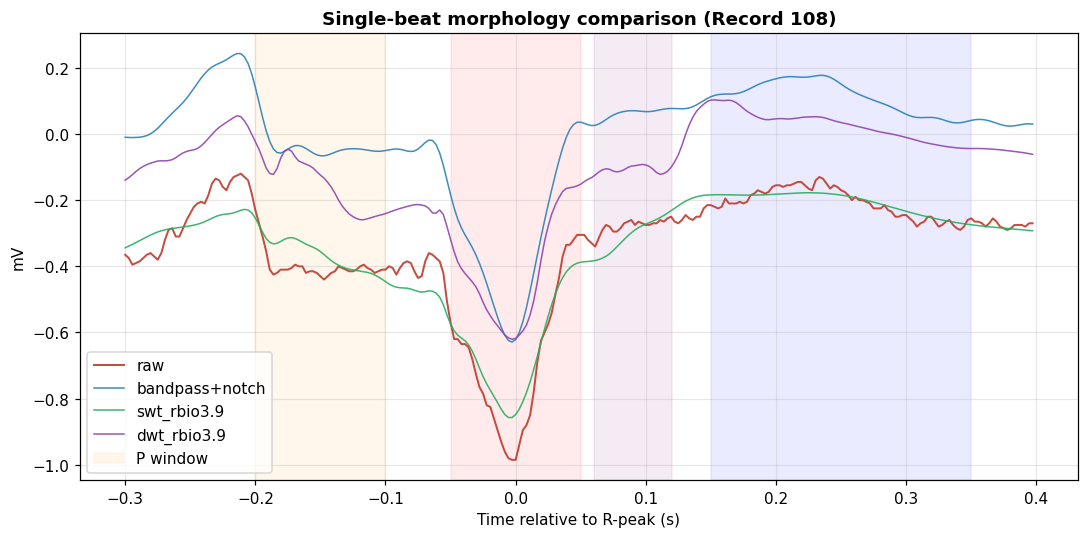

In [24]:
r = r_peaks[10]
i0, i1 = r - int(0.3 * fs_r108), r + int(0.4 * fs_r108)
t_beat = np.arange(i1 - i0) / fs_r108 - 0.3

fig, ax = plt.subplots(figsize=(10, 5))
colors = {'raw': '#c0392b', 'bandpass+notch': '#2980b9', 'swt_rbio3.9': '#27ae60', 'dwt_rbio3.9': '#8e44ad'}
for name, sig in morph_variants.items():
    ax.plot(t_beat, sig[i0:i1], label=name, color=colors[name], linewidth=1.3 if name == 'raw' else 1.0, alpha=0.9)

ax.axvspan(-0.20, -0.10, alpha=0.08, color='orange', label='P window')
ax.axvspan(-0.05, 0.05, alpha=0.08, color='red')
ax.axvspan(0.06, 0.12, alpha=0.08, color='purple')
ax.axvspan(0.15, 0.35, alpha=0.08, color='blue')
ax.set_title('Single-beat morphology comparison (Record 108)', fontweight='bold')
ax.set_xlabel('Time relative to R-peak (s)'); ax.set_ylabel('mV')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


---
# Part 2  Direct Multi-Step Transformer Forecasting of R-R Intervals (All 48 Records)



## 10. R-R Interval Extraction  All 48 Records

In [25]:
rr_by_record = {}
peaks_by_record = {}
failed_records = []

t0 = time.time()
for rec_name in records:
    try:
        peaks = detect_rpeaks(cleaned[rec_name], fs_by_record[rec_name])
        rr = np.diff(peaks) / fs_by_record[rec_name]
        rr_by_record[rec_name] = rr
        peaks_by_record[rec_name] = peaks
    except Exception as e:
        failed_records.append((rec_name, str(e)))
print(f"Extracted R-R intervals for {len(rr_by_record)}/{len(records)} records in {time.time()-t0:.1f}s")
if failed_records:
    print("Failed:", failed_records)

rr_lengths = {k: len(v) for k, v in rr_by_record.items()}
total_beats = sum(rr_lengths.values())
print(f"Total R-R intervals pooled across all records: {total_beats}")
print(f"Per-record beat count: min={min(rr_lengths.values())}, "
      f"mean={np.mean(list(rr_lengths.values())):.0f}, max={max(rr_lengths.values())}")


Extracted R-R intervals for 48/48 records in 155.5s
Total R-R intervals pooled across all records: 107782
Per-record beat count: min=1514, mean=2245, max=3358


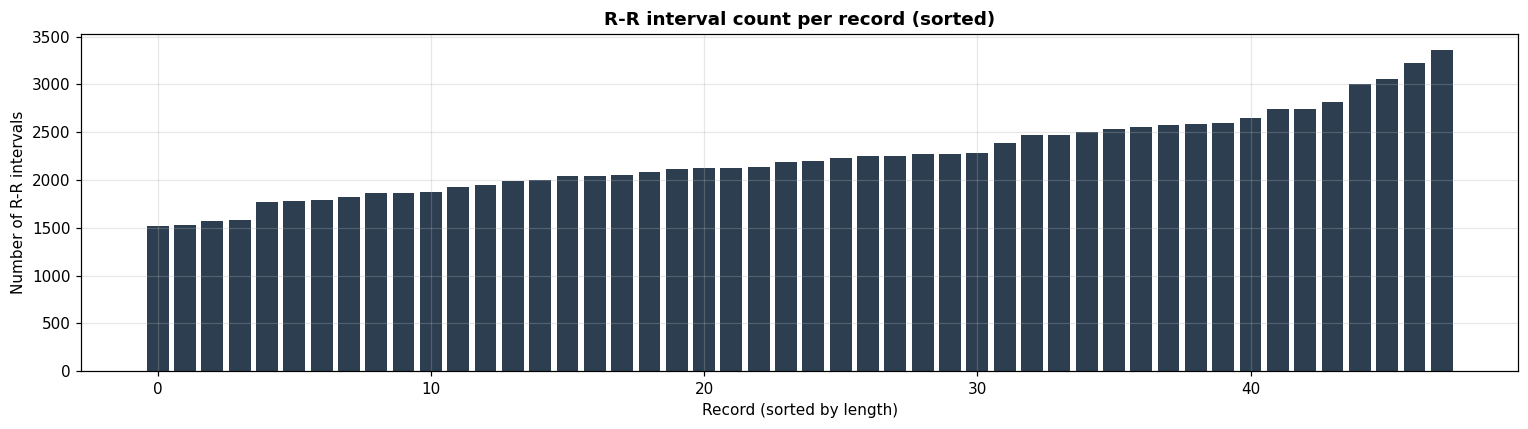

In [26]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(rr_lengths)), sorted(rr_lengths.values()), color='#2c3e50')
ax.set_title('R-R interval count per record (sorted)', fontweight='bold')
ax.set_xlabel('Record (sorted by length)'); ax.set_ylabel('Number of R-R intervals'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 11. Train/Test Split Intra-Patient, Chronological, Per Record


In [27]:
TRAIN_FRAC = 0.7   # chronological: first 70% of each record's own beats = train, last 30% = test

split_data = {}  
for rec_name, rr in rr_by_record.items():
    n_total = len(rr)
    split_idx = int(n_total * TRAIN_FRAC)
    train_raw = rr[:split_idx]
    test_raw = rr[split_idx:]

    mean, std = train_raw.mean(), train_raw.std()
    if std == 0:
        std = 1e-6  # guard against a degenerate all-identical record

    split_data[rec_name] = dict(
        train_raw=train_raw, test_raw=test_raw,
        train_scaled=(train_raw - mean) / std,
        test_scaled=(test_raw - mean) / std,
        mean=mean, std=std,
    )

print(f"Split {len(split_data)} records (train_frac={TRAIN_FRAC})")
print(f"Example — record '{records[0]}': "
      f"train={len(split_data[records[0]]['train_raw'])}, "
      f"test={len(split_data[records[0]]['test_raw'])}")


Split 48 records (train_frac=0.7)
Example — record '100': train=1590, test=682


## 12. Windowing for Direct Multi-Step (MIMO) Forecasting  Pooled Across Records

In [28]:
LOOKBACK = 50        
TRAIN_STRIDE = 5     
TEST_STRIDE = 1     
HORIZONS = [10, 20, 50]

def make_windows(series, lookback, horizon, stride=1):
    X, Y = [], []
    last_start = len(series) - lookback - horizon
    for i in range(0, last_start + 1, stride):
        X.append(series[i:i + lookback])
        Y.append(series[i + lookback:i + lookback + horizon])
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

pooled = {}
for h in HORIZONS:
    Xtr_list, Ytr_list = [], []
    Xte_list, Yte_list, rec_id_te = [], [], []
    for rec_name, sd in split_data.items():
        Xtr, Ytr = make_windows(sd['train_scaled'], LOOKBACK, h, stride=TRAIN_STRIDE)
        Xte, Yte = make_windows(sd['test_scaled'], LOOKBACK, h, stride=TEST_STRIDE)
        if len(Xtr) == 0 or len(Xte) == 0:
            continue
        Xtr_list.append(Xtr); Ytr_list.append(Ytr)
        Xte_list.append(Xte); Yte_list.append(Yte)
        rec_id_te.extend([rec_name] * len(Xte))

    pooled[h] = dict(
        Xtr=np.concatenate(Xtr_list), Ytr=np.concatenate(Ytr_list),
        Xte=np.concatenate(Xte_list), Yte=np.concatenate(Yte_list),
        rec_id_te=np.array(rec_id_te),
    )
    print(f"Horizon {h:>2}: pooled train windows={pooled[h]['Xtr'].shape}, "
          f"pooled test windows={pooled[h]['Xte'].shape} (from {len(set(rec_id_te))} records)")


Horizon 10: pooled train windows=(14539, 50), pooled test windows=(29526, 50) (from 48 records)
Horizon 20: pooled train windows=(14443, 50), pooled test windows=(29046, 50) (from 48 records)
Horizon 50: pooled train windows=(14155, 50), pooled test windows=(27606, 50) (from 48 records)


## 13. Transformer Model (Direct Multi-Step / MIMO head)

In [29]:
import torch
import torch.nn as nn

torch.manual_seed(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", DEVICE)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=200):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class RRTransformer(nn.Module):
    """Direct multi-step (MIMO) forecaster: lookback window in, all `horizon`
    future values out in a single forward pass -- no recursive feedback,
    so errors from step 1 never compound into step 2..horizon."""
    def __init__(self, lookback, horizon, d_model=64, nhead=4, num_layers=2, dim_ff=128, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(1, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=lookback + 1)
        enc_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
                                                dropout=dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.head = nn.Sequential(
            nn.Linear(d_model, dim_ff), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(dim_ff, horizon)
        )

    def forward(self, x):                       
        x = x.unsqueeze(-1)                     
        x = self.input_proj(x)                 
        x = self.pos_enc(x)
        enc = self.encoder(x)                   
        pooled_repr = enc.mean(dim=1)              
        return self.head(pooled_repr)              


Using device: cuda


## 14. Training  One Shared Model per Horizon (pooled across all 48 records)

In [30]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

EPOCHS = 15
BATCH_SIZE = 256
LR = 1e-3

def train_model(Xtr, Ytr, horizon, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR):
    model = RRTransformer(lookback=LOOKBACK, horizon=horizon).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    Xtr_t = torch.from_numpy(Xtr).to(DEVICE)
    Ytr_t = torch.from_numpy(Ytr).to(DEVICE)
    n = len(Xtr_t)

    model.train()
    for epoch in range(epochs):
        perm = torch.randperm(n)
        epoch_loss = 0.0
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            xb, yb = Xtr_t[idx], Ytr_t[idx]
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()
            epoch_loss += loss.item() * len(idx)
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"    epoch {epoch+1:>3}/{epochs}  train MSE (scaled): {epoch_loss/n:.5f}")
    return model

def evaluate_model(model, Xte, Yte, rec_id_te, split_data):
    model.eval()
    with torch.no_grad():
        Xte_t = torch.from_numpy(Xte).to(DEVICE)
        preds_scaled = model(Xte_t).cpu().numpy()

    mean_arr = np.array([split_data[r]['mean'] for r in rec_id_te]).reshape(-1, 1)
    std_arr = np.array([split_data[r]['std'] for r in rec_id_te]).reshape(-1, 1)

    preds = preds_scaled * std_arr + mean_arr
    trues = Yte * std_arr + mean_arr

    rmse = np.sqrt(mean_squared_error(trues.flatten(), preds.flatten()))
    mae = mean_absolute_error(trues.flatten(), preds.flatten())
    r2 = r2_score(trues.flatten(), preds.flatten())
    return preds, trues, rmse, mae, r2

results = {}
trained_models = {}
for h in HORIZONS:
    print(f"\n=== Training shared Transformer for horizon={h} "
          f"(train windows={len(pooled[h]['Xtr'])}) ===")
    Xtr, Ytr = pooled[h]['Xtr'], pooled[h]['Ytr']
    Xte, Yte, rec_id_te = pooled[h]['Xte'], pooled[h]['Yte'], pooled[h]['rec_id_te']

    t0 = time.time()
    model = train_model(Xtr, Ytr, horizon=h)
    train_time = time.time() - t0

    t0 = time.time()
    preds, trues, rmse, mae, r2 = evaluate_model(model, Xte, Yte, rec_id_te, split_data)
    inference_time = time.time() - t0

    results[h] = dict(preds=preds, trues=trues, rec_id_te=rec_id_te,
                       rmse=rmse, mae=mae, r2=r2,
                       train_time=train_time, inference_time=inference_time,
                       total_time=train_time + inference_time)
    trained_models[h] = model
    print(f"  RMSE={rmse:.4f}s  MAE={mae:.4f}s  R2={r2:.4f}  "
          f"train_time={train_time:.1f}s  inference_time={inference_time:.2f}s")



=== Training shared Transformer for horizon=10 (train windows=14539) ===
    epoch   1/15  train MSE (scaled): 0.92738
    epoch   5/15  train MSE (scaled): 0.87277
    epoch  10/15  train MSE (scaled): 0.86404
    epoch  15/15  train MSE (scaled): 0.85972
  RMSE=0.2369s  MAE=0.0902s  R2=0.2726  train_time=12.0s  inference_time=0.30s

=== Training shared Transformer for horizon=20 (train windows=14443) ===
    epoch   1/15  train MSE (scaled): 0.94478
    epoch   5/15  train MSE (scaled): 0.89944
    epoch  10/15  train MSE (scaled): 0.89061
    epoch  15/15  train MSE (scaled): 0.88739
  RMSE=0.2385s  MAE=0.0942s  R2=0.2634  train_time=8.2s  inference_time=0.31s

=== Training shared Transformer for horizon=50 (train windows=14155) ===
    epoch   1/15  train MSE (scaled): 0.97753
    epoch   5/15  train MSE (scaled): 0.94103
    epoch  10/15  train MSE (scaled): 0.93626
    epoch  15/15  train MSE (scaled): 0.93079
  RMSE=0.2428s  MAE=0.0974s  R2=0.2460  train_time=8.1s  inference_ti

## 15. Metrics Table (pooled across all 48 records)

In [31]:
print(f"{'Horizon':<10}{'RMSE':>10}{'MAE':>10}{'R Squared':>12}{'Compute Time (s)':>20}")
for h in HORIZONS:
    r = results[h]
    print(f"{h:<10}{r['rmse']:>10.4f}{r['mae']:>10.4f}{r['r2']:>12.4f}{r['total_time']:>20.2f}")

import pandas as pd
metrics_table = pd.DataFrame({
    'Horizon': HORIZONS,
    'RMSE': [results[h]['rmse'] for h in HORIZONS],
    'MAE': [results[h]['mae'] for h in HORIZONS],
    'R Squared': [results[h]['r2'] for h in HORIZONS],
    'Computational Time (s)': [results[h]['total_time'] for h in HORIZONS],
})
metrics_table


Horizon         RMSE       MAE   R Squared    Compute Time (s)
10            0.2369    0.0902      0.2726               12.28
20            0.2385    0.0942      0.2634                8.50
50            0.2428    0.0974      0.2460                8.41


,Horizon,RMSE,MAE,R Squared,Computational Time (s)
0,10,0.236923,0.090244,0.272605,12.280783
1,20,0.238452,0.094232,0.263447,8.496112
2,50,0.242774,0.097418,0.246027,8.414972


## 16. Insights & Visualizations

### 16a. Actual vs. Predicted across the horizon
One representative test window per horizon 

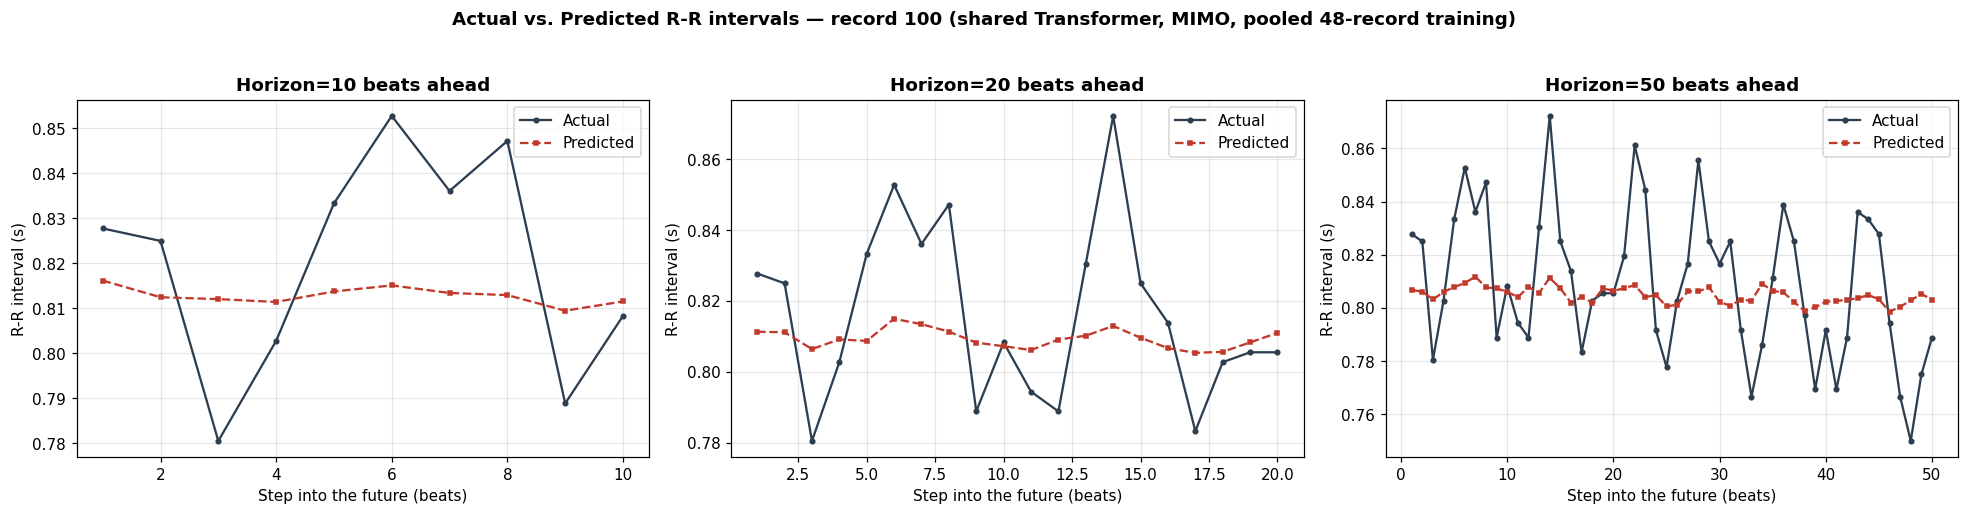

In [36]:
EXAMPLE_RECORD = '100'

fig, axes = plt.subplots(1, len(HORIZONS), figsize=(6 * len(HORIZONS), 4.5))
for ax, h in zip(axes, HORIZONS):
    r = results[h]
    idx_candidates = np.where(r['rec_id_te'] == EXAMPLE_RECORD)[0]
    example_idx = idx_candidates[0] if len(idx_candidates) else 0

    actual = r['trues'][example_idx]
    pred = r['preds'][example_idx]
    steps = np.arange(1, h + 1)
    ax.plot(steps, actual, 'o-', color='#2c3e50', label='Actual', linewidth=1.5, markersize=3)
    ax.plot(steps, pred, 's--', color='#c0392b', label='Predicted', linewidth=1.5, markersize=3)
    ax.set_title(f'Horizon={h} beats ahead', fontweight='bold')
    ax.set_xlabel('Step into the future (beats)'); ax.set_ylabel('R-R interval (s)')
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle(f'Actual vs. Predicted R-R intervals — record {EXAMPLE_RECORD} '
             f'(shared Transformer, MIMO, pooled 48-record training)', fontweight='bold', y=1.03)
plt.tight_layout(); plt.show()


### 16b. RMSE across all points in the horizon, averaged over all test samples (all 48 records)


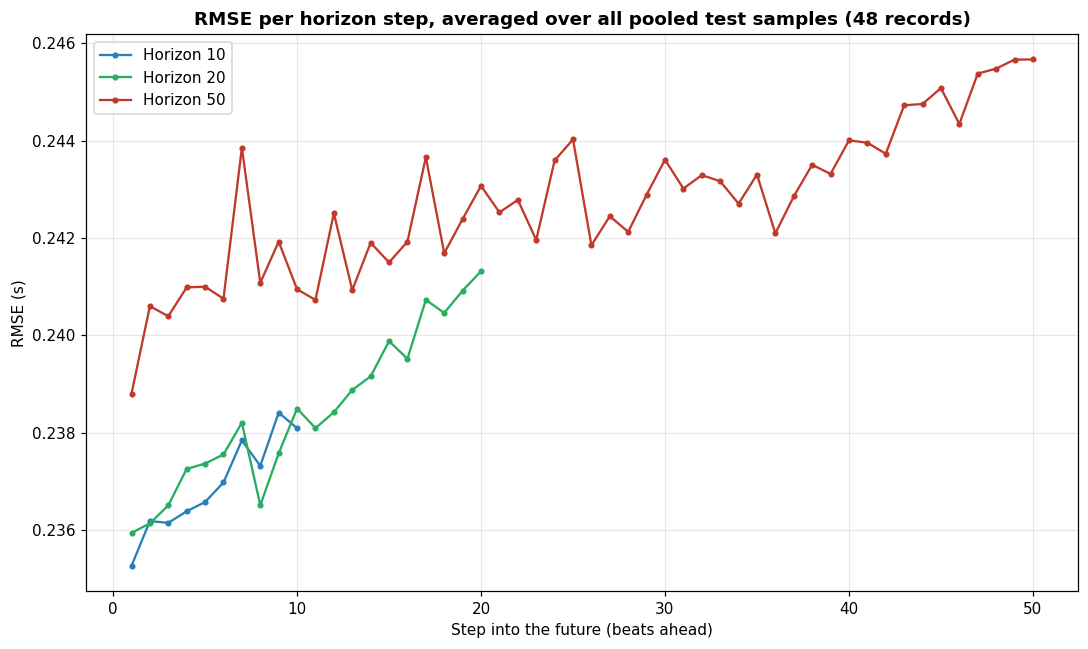

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = {10: '#2980b9', 20: '#27ae60', 50: '#c0392b'}

for h in HORIZONS:
    r = results[h]
    per_step_rmse = np.sqrt(np.mean((r['trues'] - r['preds']) ** 2, axis=0))
    ax.plot(np.arange(1, h + 1), per_step_rmse, 'o-', color=colors[h], label=f'Horizon {h}',
            linewidth=1.5, markersize=3)

ax.set_title('RMSE per horizon step, averaged over all pooled test samples (48 records)', fontweight='bold')
ax.set_xlabel('Step into the future (beats ahead)'); ax.set_ylabel('RMSE (s)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### 16c. Per-record RMSE breakdown where the model fails by patient
Since one shared model is evaluated across 48 different patients, per-record
error variation directly shows which rhythm types/records are hardest.

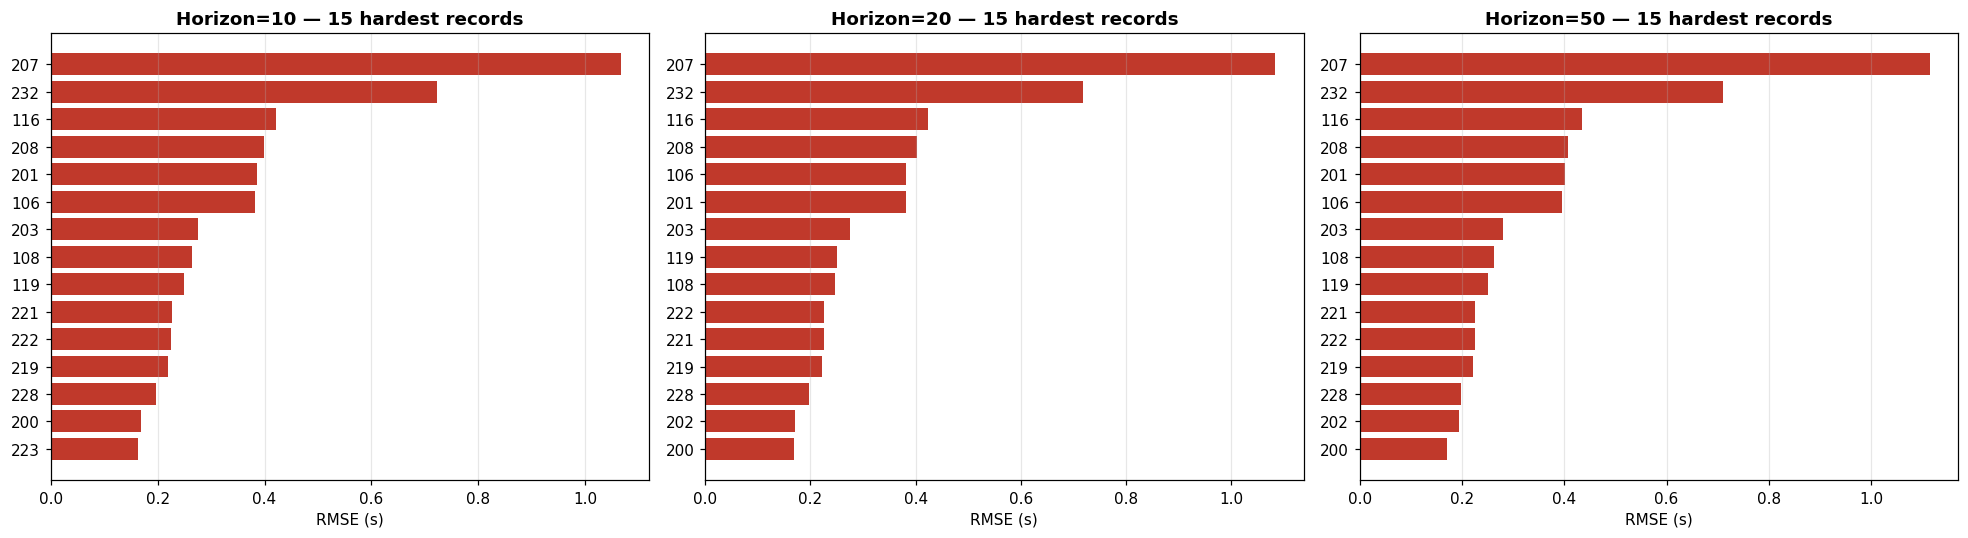

Horizon 10: worst record = 207 (RMSE=1.0660s), best record = 112 (RMSE=0.0141s)
Horizon 20: worst record = 207 (RMSE=1.0832s), best record = 112 (RMSE=0.0159s)
Horizon 50: worst record = 207 (RMSE=1.1140s), best record = 112 (RMSE=0.0170s)


In [34]:
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(6 * len(HORIZONS), 5))

worst_records = {}
for ax, h in zip(axes, HORIZONS):
    r = results[h]
    per_beat_sq_err = np.mean((r['trues'] - r['preds']) ** 2, axis=1)   # per test window
    df = pd.DataFrame({'record': r['rec_id_te'], 'sq_err': per_beat_sq_err})
    rmse_by_record = df.groupby('record')['sq_err'].mean().apply(np.sqrt).sort_values(ascending=False)
    worst_records[h] = rmse_by_record

    top15 = rmse_by_record.head(15)
    ax.barh(top15.index[::-1], top15.values[::-1], color='#c0392b')
    ax.set_title(f'Horizon={h} — 15 hardest records', fontweight='bold')
    ax.set_xlabel('RMSE (s)')
    ax.grid(alpha=0.3, axis='x')

plt.tight_layout(); plt.show()

for h in HORIZONS:
    print(f"Horizon {h}: worst record = {worst_records[h].index[0]} "
          f"(RMSE={worst_records[h].iloc[0]:.4f}s), "
          f"best record = {worst_records[h].index[-1]} (RMSE={worst_records[h].iloc[-1]:.4f}s)")
